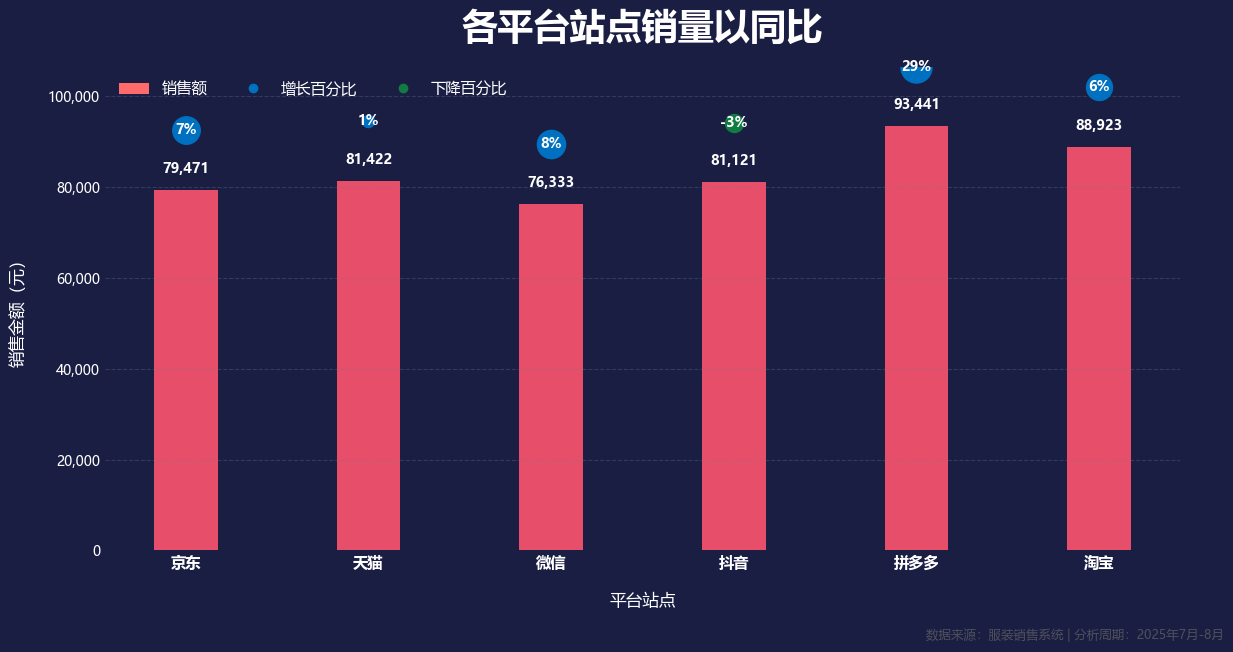

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, FuncFormatter

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取数据文件
    orders = pd.read_csv('../../数据生成/erp_order.csv', encoding='utf-8-sig')

    # 验证必需字段存在
    required_columns = ['下单时间', '平台站点', '商品金额']
    for col in required_columns:
        if col not in orders.columns:
            raise ValueError(f"数据缺失必要字段: {col}")

    # 转换并清洗时间数据，确保数据有效
    orders['下单时间'] = pd.to_datetime(orders['下单时间'], errors='coerce')
    orders = orders[orders['下单时间'].notnull()]

    # 提取年份和月份用于筛选
    orders['年份'] = orders['下单时间'].dt.year
    orders['月份'] = orders['下单时间'].dt.month

    # 筛选数据
    orders = orders[(orders['年份'] == 2025) & (orders['月份'].isin([7, 8]))]
    if orders.empty:
        raise ValueError("2025年7月或8月的数据为空")

    # 按平台和月份聚合销售数据
    platform_sales = orders.groupby(['平台站点', '月份'])['商品金额'].sum().reset_index()
    
    # 构建透视表用于后续分析
    pivot_data = platform_sales.pivot(index='平台站点', columns='月份', values='商品金额').reset_index()

    # 确保透视表包含所有月份数据，必要时填充0
    for month in [7, 8]:
        if month not in pivot_data.columns:
            pivot_data[month] = 0

    # 转换数据类型并填补空缺
    pivot_data = pivot_data.fillna(0)
    pivot_data[7] = pd.to_numeric(pivot_data[7], errors='coerce').fillna(0)
    pivot_data[8] = pd.to_numeric(pivot_data[8], errors='coerce').fillna(0)

    # 提取绘图所需数据：平台名及销量数据
    platforms = pivot_data['平台站点'].tolist()
    sales_may = pivot_data[7].tolist()
    sales_jun = pivot_data[8].tolist()

    # 计算同比增幅百分比
    percentage_changes = [
        (sales_jun[i] - sales_may[i]) / sales_may[i] * 100 if sales_may[i] != 0 else 0
        for i in range(len(sales_may))
    ]

    # 开始绘制图表
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor('#1A1E43')
    ax.set_facecolor('#1A1E43')

    x = np.arange(len(platforms))
    bar_width = 0.35

    # 绘制销售额柱状图
    bars_jun = ax.bar(x, sales_jun, bar_width, color='#e74e69', edgecolor='none')

    # 在柱顶标注销售额
    for i, bar in enumerate(bars_jun):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(sales_jun) * 0.03,
            f'{int(height):,}',
            ha='center', va='bottom',
            color='white', fontweight='bold', fontsize=10
    )

    # 增长百分比：整体上移且自适应
    offset = max(sales_jun) * 0.14 if max(sales_jun) > 0 else 50  # 自适应上移
    max_size = 500  # 设置最大尺寸
    scaling_factor = 50  # 设置增长率

    for i, pct_change in enumerate(percentage_changes):
        y_pos = sales_jun[i] + offset
        # 根据增长百分比调整小球大小，确保最小小球也有可见大小
        size = max(40, min(max_size, abs(pct_change) * scaling_factor))
        ax.scatter(x[i], y_pos, s=size, color='#0070c0' if pct_change > 0 else '#107c41', zorder=5)
        # 将文字放在小球上
        ax.text(
            x[i], y_pos, f'{int(pct_change)}%',
            ha='center', va='center',
            color='white', fontsize=10, fontweight='bold', zorder=6
    )

    # 坐标轴与刻度样式设定
    ylim_top = max(sales_jun) + offset
    ax.set_ylim(0, ylim_top)
    ax.yaxis.set_major_locator(MultipleLocator(20000))

    ax.set_xticks(x)
    ax.set_xticklabels(platforms, color="#ffffff", fontsize=11, fontweight='bold')

    ax.tick_params(axis='x', length=0, colors='#ffffff')
    ax.tick_params(axis='y', length=0, colors='#ffffff')

    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{int(v):,}'))

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.title('各平台站点销量以同比', fontsize=26, fontweight='bold', color="#ffffff", pad=20)
    ax.set_xlabel('平台站点', fontsize=12, color="#ffffff", labelpad=15)
    ax.set_ylabel('销售金额（元）', fontsize=12, color="#ffffff", labelpad=15)

    legend_handles = [
        Patch(facecolor='#ff6b6b', edgecolor='none', label='销售额'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='#0070c0', 
                markeredgecolor='#0070c0', label='增长百分比'),
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='#107c41',
                markeredgecolor='#107c41', label='下降百分比'),
    ]
    
    # 添加网格线
    ax.grid(axis='y', linestyle="--", alpha=0.3, color='#777b92')
    ax.grid(axis='x', visible=False)
    
    # 设置图例
    leg = ax.legend(handles=legend_handles, loc='upper left', frameon=False, ncol=3, prop={'size': 11})
    for text in leg.get_texts():
        text.set_color('#ffffff')
    
    # 添加数据来源说明
    plt.figtext(0.9, 0.03, '数据来源：服装销售系统 | 分析周期：2025年7月-8月',
                ha='center', fontsize=9, color='#666666', alpha=0.7)
    
    # 调整布局
    plt.tight_layout(rect=(0.0, 0.05, 1.0, 0.95))
    
    # 保存图表
    plt.savefig('各平台站点销量以同比.png',
                dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())

    # 显示绘制结果
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")

# 分析

- **京东**：
  - 销售额：79,471元
  - 同比增长：7%
  - 分析：京东平台销售额呈现稳定增长，增长率为7%，显示出该平台在市场中的稳健表现。

- **天猫**：
  - 销售额：81,422元
  - 同比增长：1%
  - 分析：天猫平台销售额微幅增长，增长率为1%，表明市场表现相对稳定。

- **微信**：
  - 销售额：76,333元
  - 同比增长：8%
  - 分析：微信平台销售额实现了8%的增长，显示出该平台在社交电商领域的潜力。

- **抖音**：
  - 销售额：81,121元
  - 同比下降：3%
  - 分析：抖音平台销售额同比下降3%，可能受到市场竞争加剧或用户行为变化的影响。

- **拼多多**：
  - 销售额：93,441元
  - 同比增长：29%
  - 分析：拼多多平台销售额显著增长，增长率达到29%，显示出强劲的市场扩张能力。

- **淘宝**：
  - 销售额：88,923元
  - 同比增长：6%
  - 分析：淘宝平台销售额实现了6%的增长，保持了良好的市场竞争力。


# 结论

从各平台站点的销量同比变化来看，拼多多和淘宝的销售额增长最为显著，分别增长了29%和6%，这可能与平台的市场策略、用户基础及促销活动有关。京东和微信也实现了正增长，而天猫的增长率最低，仅为1%。抖音是唯一一个出现负增长的平台，下降了3%，这可能需要进一步分析原因并采取措施以改善业绩。